In [21]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.cross_decomposition import CCA

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

In [22]:
# Load and clean data
df = pd.read_csv('HR_data_2.csv')
df_clean = df.dropna().reset_index(drop=True)

print(f"Raw shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")

Raw shape: (312, 71)
Clean shape: (307, 71)


In [23]:
# Features
biosignal_cols = [c for c in df_clean.columns if c.startswith(('HR_TD_', 'TEMP_TD_', 'EDA_TD_'))]
meta_cols = ['Phase', 'Individual', 'Cohort', 'Round', 'Puzzler', 'Team_ID']

X_raw = df_clean[biosignal_cols].astype(float).copy()
meta = df_clean[meta_cols].copy()

In [24]:
# Handle skewness 
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = X_raw.copy()

for subj in meta['Individual'].unique():
    idx = meta['Individual'] == subj
    X_scaled.loc[idx, biosignal_cols] = pt.fit_transform(X_raw.loc[idx])

In [25]:
# Split for CCA 
hr_cols = [c for c in biosignal_cols if c.startswith('HR_TD_')]
eda_temp_cols = [c for c in biosignal_cols if c.startswith(('EDA_TD_', 'TEMP_TD_'))]

X_hr = X_scaled[hr_cols].values
X_eda_temp = X_scaled[eda_temp_cols].values
phase_labels = meta['Phase'].values
individual_ids = meta['Individual'].values

In [26]:
# CCA cross validation
from sklearn.model_selection import LeaveOneGroupOut

max_comp = min(X_hr.shape[1], X_eda_temp.shape[1])

def validate_cca_components_loso(X, Y, groups, max_components):
    """Leave-one-subject-out cross-validation for CCA"""
    logo = LeaveOneGroupOut()  # Define INSIDE the function
    cv_scores = []
    
    for n_comp in range(1, min(max_components, 11)):
        fold_corrs = []
        
        for train_idx, val_idx in logo.split(X, groups=groups):
            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]
            
            cca = CCA(n_components=n_comp)
            cca.fit(X_train, Y_train)
            X_val_c, Y_val_c = cca.transform(X_val, Y_val)
            
            corrs = [np.corrcoef(X_val_c[:, i], Y_val_c[:, i])[0, 1] 
                     for i in range(n_comp)]
            fold_corrs.append(np.mean(corrs))
        
        cv_scores.append(np.mean(fold_corrs))
    
    return cv_scores

# Run LOSO CV
cca_cv_scores = validate_cca_components_loso(X_hr, X_eda_temp, individual_ids, max_comp)
optimal_n_cca = np.argmax(cca_cv_scores) + 1

print("CCA LOSO Cross-Validation Results (HR vs EDA+TEMP):")
for i, score in enumerate(cca_cv_scores[:10]):
    print(f"  {i+1} component(s): mean validation correlation = {score:.4f}")
print(f"\nOptimal number of components: {optimal_n_cca}")
print(f"  (Highest validation correlation: {cca_cv_scores[optimal_n_cca-1]:.4f})")

CCA LOSO Cross-Validation Results (HR vs EDA+TEMP):
  1 component(s): mean validation correlation = 0.4553
  2 component(s): mean validation correlation = 0.2506
  3 component(s): mean validation correlation = 0.2327
  4 component(s): mean validation correlation = 0.1431
  5 component(s): mean validation correlation = 0.0714
  6 component(s): mean validation correlation = 0.0525
  7 component(s): mean validation correlation = 0.0386
  8 component(s): mean validation correlation = 0.0408
  9 component(s): mean validation correlation = 0.0335
  10 component(s): mean validation correlation = 0.0365

Optimal number of components: 1
  (Highest validation correlation: 0.4553)


In [37]:
# Run CCA 
n_components = optimal_n  
cca = CCA(n_components=n_components)
cca.fit(X_hr, X_eda_temp)
X_hr_c, X_eda_temp_c = cca.transform(X_hr, X_eda_temp)

In [28]:
# Canonical correlations
def get_canonical_correlations(cca_model, X, Y):
    X_c, Y_c = cca_model.transform(X, Y)
    return [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(X_c.shape[1])]

canonical_corrs = get_canonical_correlations(cca, X_hr, X_eda_temp)

for i, corr in enumerate(canonical_corrs[:5]):
    print(f"Component {i+1}: {corr:.4f}")

Component 1: 0.7118


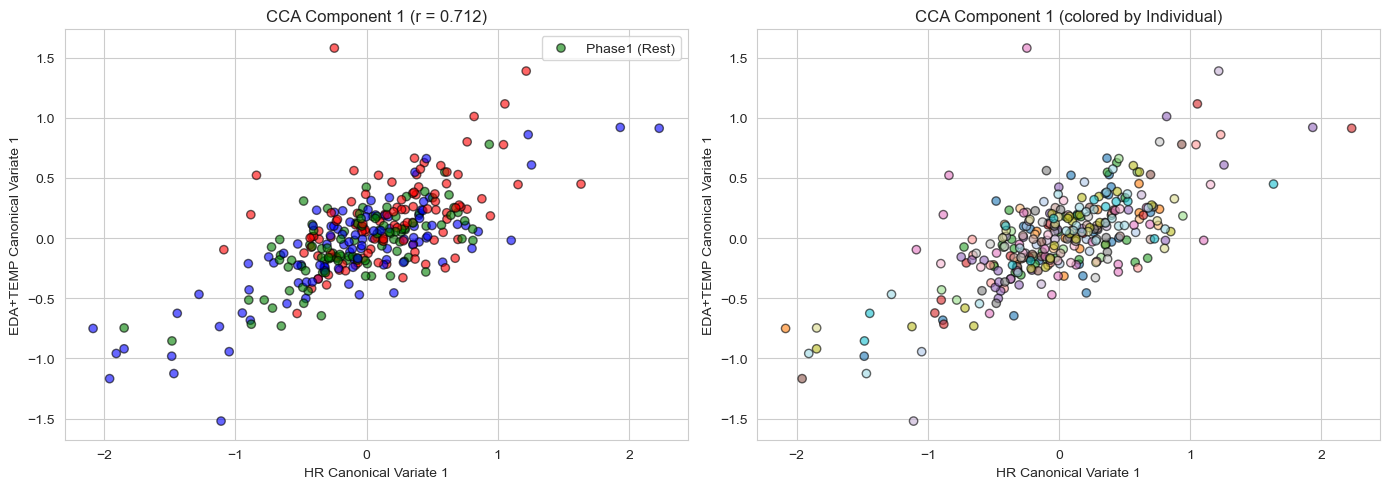

In [38]:
# Visualise canonical variates 
phase_colors = {'phase1': 'blue', 'phase2': 'red', 'phase3': 'green'}
colors = [phase_colors[p] for p in phase_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_hr_c[:, 0], X_eda_temp_c[:, 0], c=colors, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('HR Canonical Variate 1')
axes[0].set_ylabel('EDA+TEMP Canonical Variate 1')
axes[0].set_title(f'CCA Component 1 (r = {canonical_corrs[0]:.3f})')
axes[0].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])

unique_indiv = np.unique(individual_ids)
indiv_colors = {ind: i for i, ind in enumerate(unique_indiv)}
indiv_color_nums = [indiv_colors[ind] for ind in individual_ids]

scatter = axes[1].scatter(X_hr_c[:, 0], X_eda_temp_c[:, 0], c=indiv_color_nums, cmap='tab20', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('HR Canonical Variate 1')
axes[1].set_ylabel('EDA+TEMP Canonical Variate 1')
axes[1].set_title('CCA Component 1 (colored by Individual)')

plt.tight_layout()
plt.show()

In [30]:
print(meta['Phase'].unique())

['phase3' 'phase2' 'phase1']


In [39]:
# Resting vs Puzzle 
resting_mask = meta['Phase'] == 'phase1'
puzzle_mask = meta['Phase'] == 'phase2'

print(f"Phase1 (Resting): {resting_mask.sum()} samples")
print(f"Phase2 (Puzzle): {puzzle_mask.sum()} samples")

cca_resting = CCA(n_components=n_components)
cca_resting.fit(X_hr[resting_mask], X_eda_temp[resting_mask])
X_hr_c_r, X_et_c_r = cca_resting.transform(X_hr[resting_mask], X_eda_temp[resting_mask])
corr_r = np.corrcoef(X_hr_c_r[:, 0], X_et_c_r[:, 0])[0, 1]

cca_puzzle = CCA(n_components=n_components)
cca_puzzle.fit(X_hr[puzzle_mask], X_eda_temp[puzzle_mask])
X_hr_c_p, X_et_c_p = cca_puzzle.transform(X_hr[puzzle_mask], X_eda_temp[puzzle_mask])
corr_p = np.corrcoef(X_hr_c_p[:, 0], X_et_c_p[:, 0])[0, 1]

print(f"Resting (phase1): r = {corr_r:.4f}")
print(f"Puzzle (phase2): r = {corr_p:.4f}")
print(f"Difference (Puzzle - Resting): {corr_p - corr_r:.4f}")

Phase1 (Resting): 100 samples
Phase2 (Puzzle): 104 samples
Resting (phase1): r = 0.9314
Puzzle (phase2): r = 0.8264
Difference (Puzzle - Resting): -0.1050


In [40]:
# Feature loading 
hr_loadings = pd.DataFrame(
    cca.x_rotations_,
    index=hr_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.x_rotations_.shape[1])]
)

print("\nHR Features (top 5 on Component 1):")
hr_sorted = hr_loadings['Comp_1'].abs().sort_values(ascending=False)
for i, (feature, loading) in enumerate(hr_sorted.head(5).items()):
    sign = '+' if hr_loadings.loc[feature, 'Comp_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")

et_loadings = pd.DataFrame(
    cca.y_rotations_,
    index=eda_temp_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.y_rotations_.shape[1])]
)

print("\nEDA+TEMP Features (top 5 on Component 1):")
et_sorted = et_loadings['Comp_1'].abs().sort_values(ascending=False)
for i, (feature, loading) in enumerate(et_sorted.head(5).items()):
    sign = '+' if et_loadings.loc[feature, 'Comp_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")


HR Features (top 5 on Component 1):
  1. HR_TD_AUC: +0.780
  2. HR_TD_Mean: -0.425
  3. HR_TD_Slope: +0.292
  4. HR_TD_Slope_mean: -0.273
  5. HR_TD_Max: +0.145

EDA+TEMP Features (top 5 on Component 1):
  1. EDA_TD_T_AUC: +0.548
  2. EDA_TD_T_Mean: -0.488
  3. TEMP_TD_Mean: -0.360
  4. TEMP_TD_Min: +0.352
  5. EDA_TD_P_std: -0.182


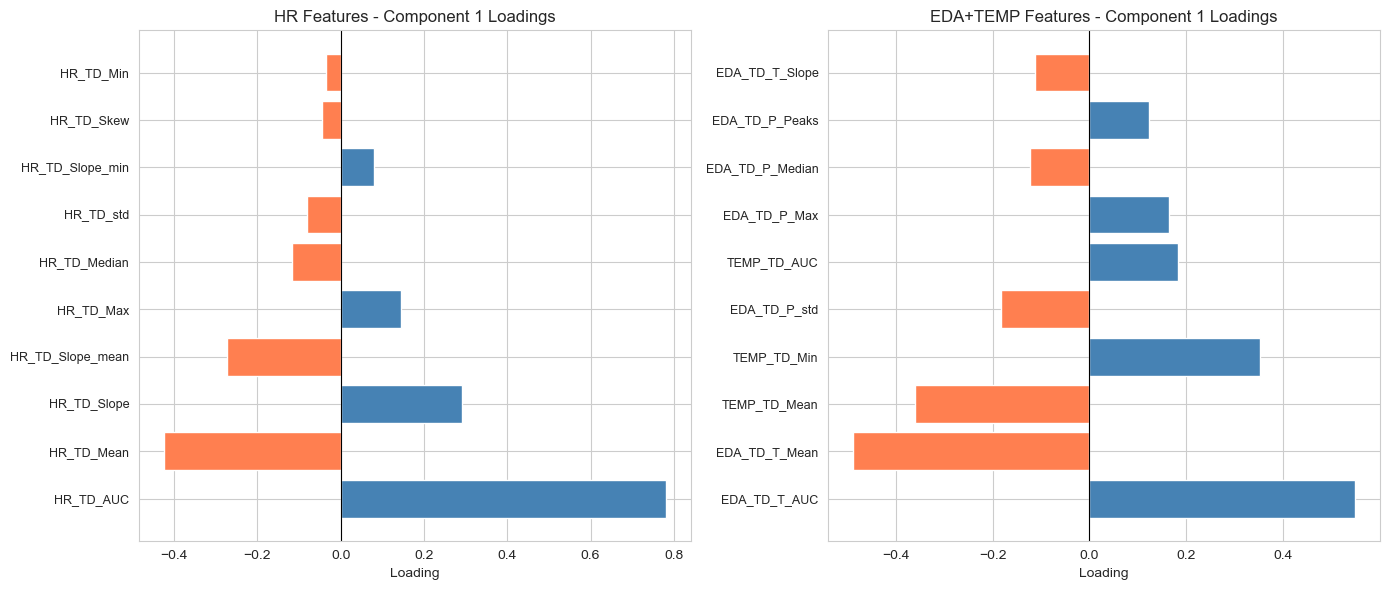

In [41]:
# Visualise top feature loadings 
hr_loadings = pd.DataFrame(
    cca.x_rotations_,
    index=hr_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.x_rotations_.shape[1])]
)

hr_top10 = hr_loadings['Comp_1'].abs().sort_values(ascending=False).head(10)
hr_top10_signed = hr_loadings.loc[hr_top10.index, 'Comp_1']

# Get top 10 EDA+TEMP loadings for Component 1
et_loadings = pd.DataFrame(
    cca.y_rotations_,
    index=eda_temp_cols,
    columns=[f'Comp_{i+1}' for i in range(cca.y_rotations_.shape[1])]
)

et_top10 = et_loadings['Comp_1'].abs().sort_values(ascending=False).head(10)
et_top10_signed = et_loadings.loc[et_top10.index, 'Comp_1']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HR loadings
colors_hr = ['steelblue' if x > 0 else 'coral' for x in hr_top10_signed.values]
axes[0].barh(range(len(hr_top10_signed)), hr_top10_signed.values, color=colors_hr)
axes[0].set_yticks(range(len(hr_top10_signed)))
axes[0].set_yticklabels(hr_top10_signed.index, fontsize=9)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('Loading')
axes[0].set_title('HR Features - Component 1 Loadings')

# EDA+TEMP loadings
colors_et = ['steelblue' if x > 0 else 'coral' for x in et_top10_signed.values]
axes[1].barh(range(len(et_top10_signed)), et_top10_signed.values, color=colors_et)
axes[1].set_yticks(range(len(et_top10_signed)))
axes[1].set_yticklabels(et_top10_signed.index, fontsize=9)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Loading')
axes[1].set_title('EDA+TEMP Features - Component 1 Loadings')

plt.tight_layout()
plt.show()

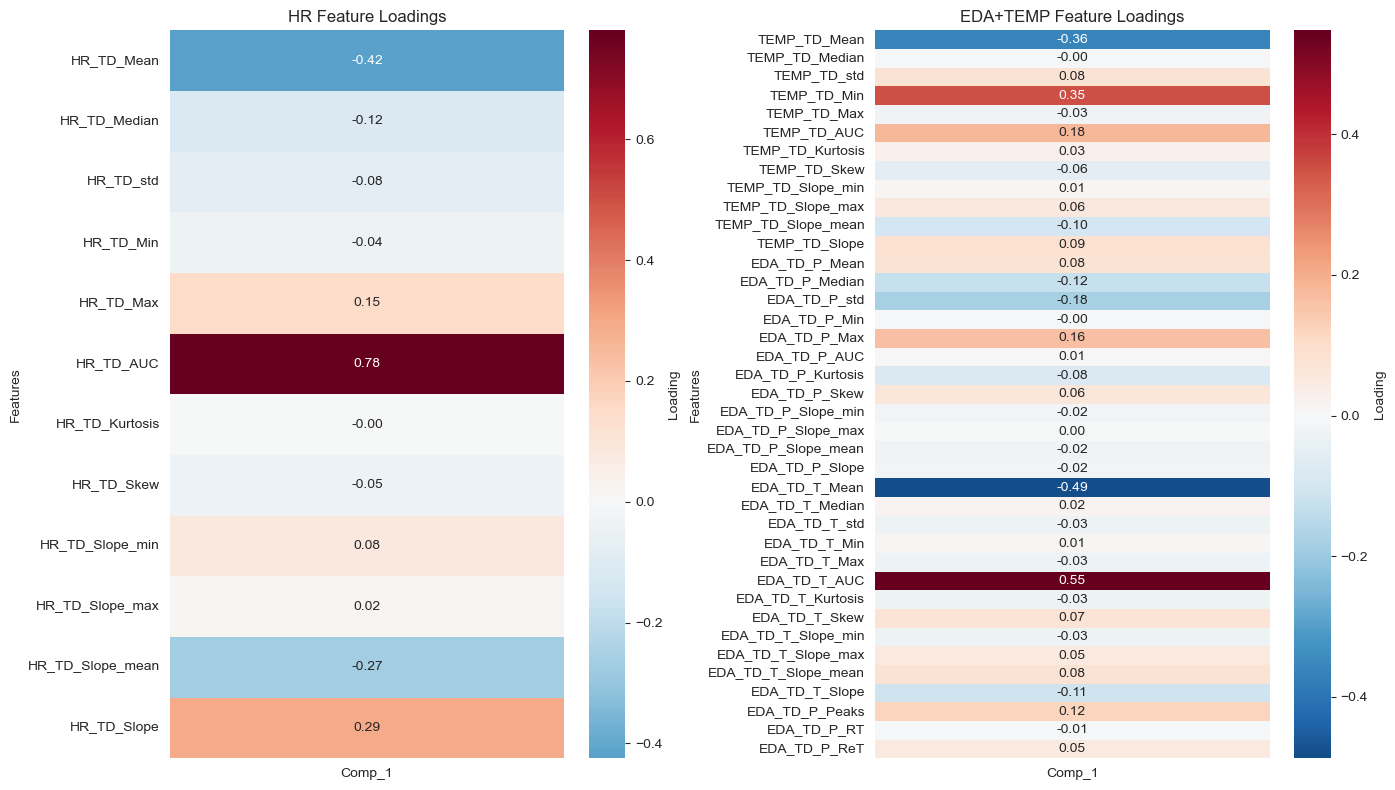

In [42]:
# Heatmap of loadings
hr_loadings_small = hr_loadings.iloc[:, :min(5, hr_loadings.shape[1])]
et_loadings_small = et_loadings.iloc[:, :min(5, et_loadings.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# HR heatmap
sns.heatmap(hr_loadings_small, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[0], cbar_kws={'label': 'Loading'})
axes[0].set_title('HR Feature Loadings')
axes[0].set_ylabel('Features')

# EDA+TEMP heatmap
sns.heatmap(et_loadings_small, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[1], cbar_kws={'label': 'Loading'})
axes[1].set_title('EDA+TEMP Feature Loadings')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

In [52]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cross_decomposition import PLSRegression

# Prepare data for PLS
biosignal_cols = [c for c in df_clean.columns if c.startswith(('HR_TD_', 'TEMP_TD_', 'EDA_TD_'))]
questionnaire_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 
                      'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']

X_biosignals = X_scaled[biosignal_cols].values
Y_quest = df_clean[questionnaire_cols].values

max_comp_pls = min(X_biosignals.shape[1], Y_quest.shape[1])

def validate_pls_components_loso(X, Y, groups, max_components):
    """Leave-one-subject-out cross-validation for PLS"""
    logo = LeaveOneGroupOut()
    cv_scores = []
    
    for n_comp in range(1, min(max_components, 11)):
        fold_r2 = []
        
        for train_idx, val_idx in logo.split(X, groups=groups):
            X_train, X_val = X[train_idx], X[val_idx]
            Y_train, Y_val = Y[train_idx], Y[val_idx]
            
            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train, Y_train)
            fold_r2.append(pls.score(X_val, Y_val))
        
        cv_scores.append(np.mean(fold_r2))
    
    return cv_scores

# Run PLS LOSO CV
pls_cv_scores = validate_pls_components_loso(X_biosignals, Y_quest, individual_ids, max_comp_pls)
optimal_n_pls = np.argmax(pls_cv_scores) + 1

print("PLS LOSO Cross-Validation Results (Biosignals vs Questionnaires):")
for i, score in enumerate(pls_cv_scores[:10]):
    print(f"  {i+1} component(s): mean R² = {score:.4f}")
print(f"\nOptimal number of components: {optimal_n_pls}")
print(f"  (Highest validation R²: {pls_cv_scores[optimal_n_pls-1]:.4f})")



PLS LOSO Cross-Validation Results (Biosignals vs Questionnaires):
  1 component(s): mean R² = -1.0111
  2 component(s): mean R² = -1.0139
  3 component(s): mean R² = -1.0281
  4 component(s): mean R² = -1.0446
  5 component(s): mean R² = -1.0643
  6 component(s): mean R² = -1.0790
  7 component(s): mean R² = -1.1047
  8 component(s): mean R² = -1.1195
  9 component(s): mean R² = -1.1259
  10 component(s): mean R² = -1.1328

Optimal number of components: 1
  (Highest validation R²: -1.0111)


Actual number of PLS components: 1


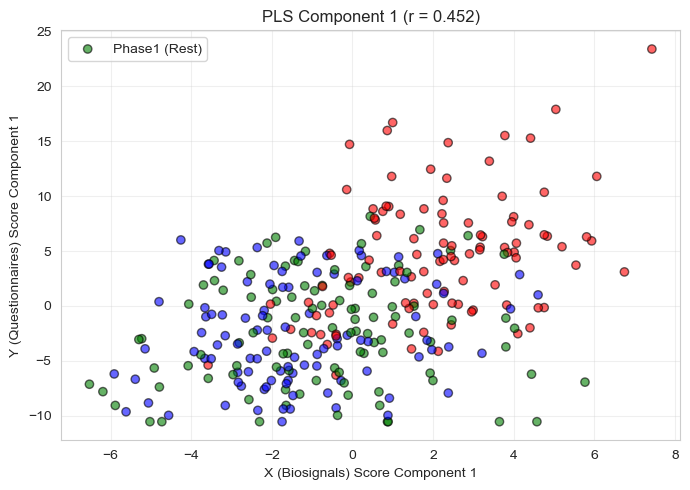

Note: Only 1 PLS component available (cannot plot Component 2)


In [55]:
n_components_actual = X_scores.shape[1]
print(f"Actual number of PLS components: {n_components_actual}")

# Color by Phase
phase_colors = ['blue' if p == 'phase1' else 'red' if p == 'phase2' else 'green' for p in phase_labels]

if n_components_actual >= 2:
    # Two or more components - show both plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: X scores vs Y scores
    axes[0].scatter(X_scores[:, 0], Y_scores[:, 0], c=phase_colors, alpha=0.6, edgecolors='k')
    axes[0].set_xlabel('X (Biosignals) Score Component 1')
    axes[0].set_ylabel('Y (Questionnaires) Score Component 1')
    axes[0].set_title(f'PLS Component 1 (r = {correlations_pls[0]:.3f})')
    axes[0].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: X scores Component 1 vs Component 2
    axes[1].scatter(X_scores[:, 0], X_scores[:, 1], c=phase_colors, alpha=0.6, edgecolors='k')
    axes[1].set_xlabel('X Score Component 1')
    axes[1].set_ylabel('X Score Component 2')
    axes[1].set_title('PLS: Biosignals Projection')
    axes[1].legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    # Only 1 component - show single plot
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    
    axes.scatter(X_scores[:, 0], Y_scores[:, 0], c=phase_colors, alpha=0.6, edgecolors='k')
    axes.set_xlabel('X (Biosignals) Score Component 1')
    axes.set_ylabel('Y (Questionnaires) Score Component 1')
    axes.set_title(f'PLS Component 1 (r = {correlations_pls[0]:.3f})')
    axes.legend(['Phase1 (Rest)', 'Phase2 (Puzzle)', 'Phase3 (Recovery)'])
    axes.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Note: Only 1 PLS component available (cannot plot Component 2)")


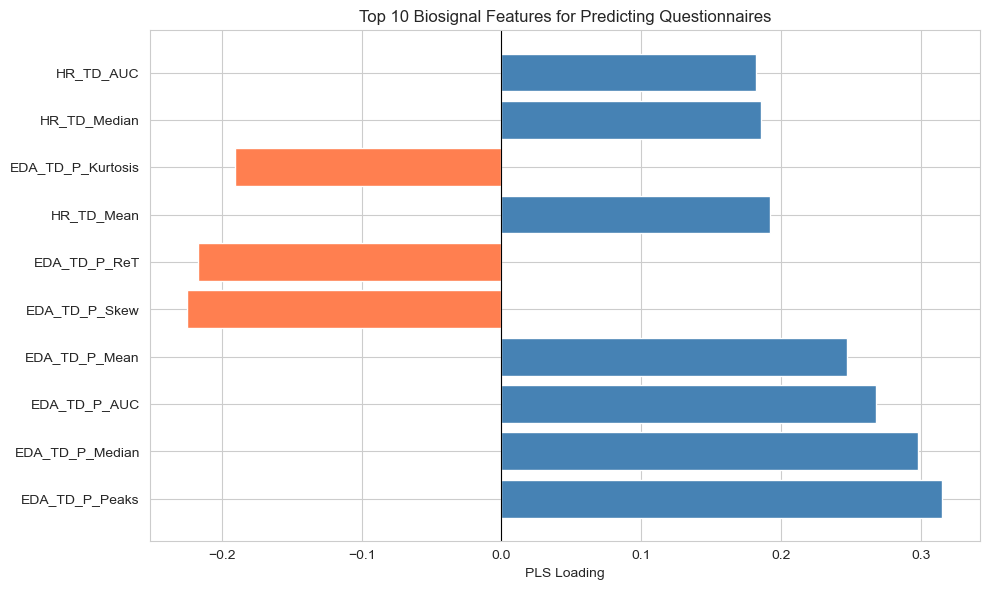


Top 5 Biosignal Features for Component 1:
  1. EDA_TD_P_Peaks: +0.315
  2. EDA_TD_P_Median: +0.298
  3. EDA_TD_P_AUC: +0.268
  4. EDA_TD_P_Mean: +0.247
  5. EDA_TD_P_Skew: -0.225


In [56]:
# PLS Feature Loadings
pls_loadings = pd.DataFrame(
    pls_model.x_rotations_,
    index=biosignal_cols,
    columns=[f'Component_{i+1}' for i in range(pls_model.x_rotations_.shape[1])]
)

# Top features for Component 1
top_features = pls_loadings['Component_1'].abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'coral' for x in pls_loadings.loc[top_features.index, 'Component_1']]
plt.barh(range(len(top_features)), pls_loadings.loc[top_features.index, 'Component_1'], color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('PLS Loading')
plt.title('Top 10 Biosignal Features for Predicting Questionnaires')
plt.tight_layout()
plt.show()

print("\nTop 5 Biosignal Features for Component 1:")
for i, (feature, loading) in enumerate(top_features.head(5).items()):
    sign = '+' if pls_loadings.loc[feature, 'Component_1'] > 0 else '-'
    print(f"  {i+1}. {feature}: {sign}{abs(loading):.3f}")

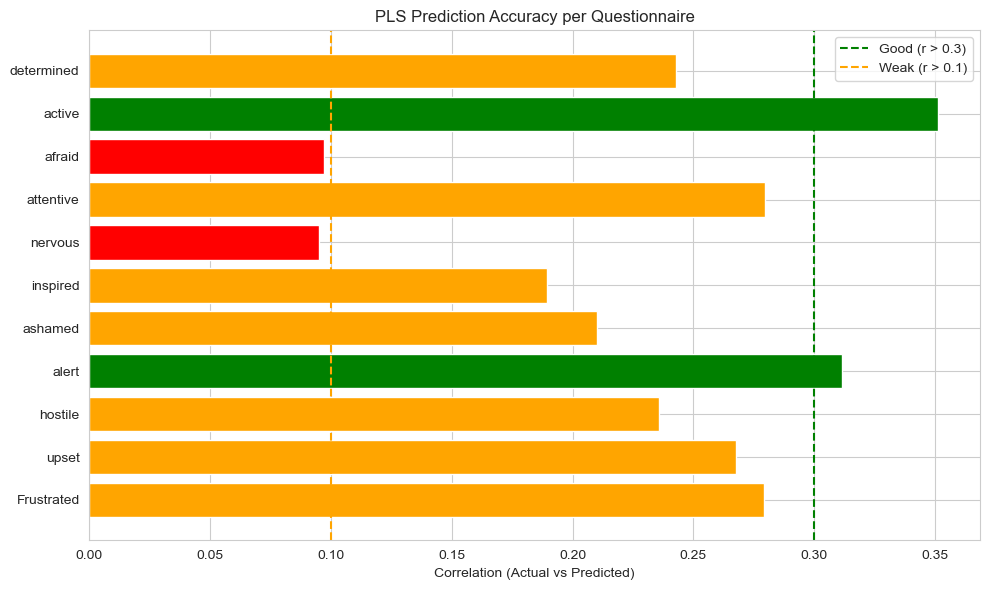


Prediction correlations per questionnaire:
  Frustrated: 0.2791
  upset: 0.2675
  hostile: 0.2359
  alert: 0.3113
  ashamed: 0.2101
  inspired: 0.1894
  nervous: 0.0952
  attentive: 0.2797
  afraid: 0.0969
  active: 0.3511
  determined: 0.2426


In [57]:
# Prediction accuracy per questionnaire
y_pred = pls_model.predict(X_biosignals)
prediction_corrs = []

for i, col in enumerate(questionnaire_cols):
    corr = np.corrcoef(Y_quest[:, i], y_pred[:, i])[0, 1]
    prediction_corrs.append(corr)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0.3 else 'orange' if c > 0.1 else 'red' for c in prediction_corrs]
plt.barh(questionnaire_cols, prediction_corrs, color=colors)
plt.axvline(x=0.3, color='green', linestyle='--', label='Good (r > 0.3)')
plt.axvline(x=0.1, color='orange', linestyle='--', label='Weak (r > 0.1)')
plt.xlabel('Correlation (Actual vs Predicted)')
plt.title('PLS Prediction Accuracy per Questionnaire')
plt.legend()
plt.tight_layout()
plt.show()

print("\nPrediction correlations per questionnaire:")
for col, corr in zip(questionnaire_cols, prediction_corrs):
    print(f"  {col}: {corr:.4f}")

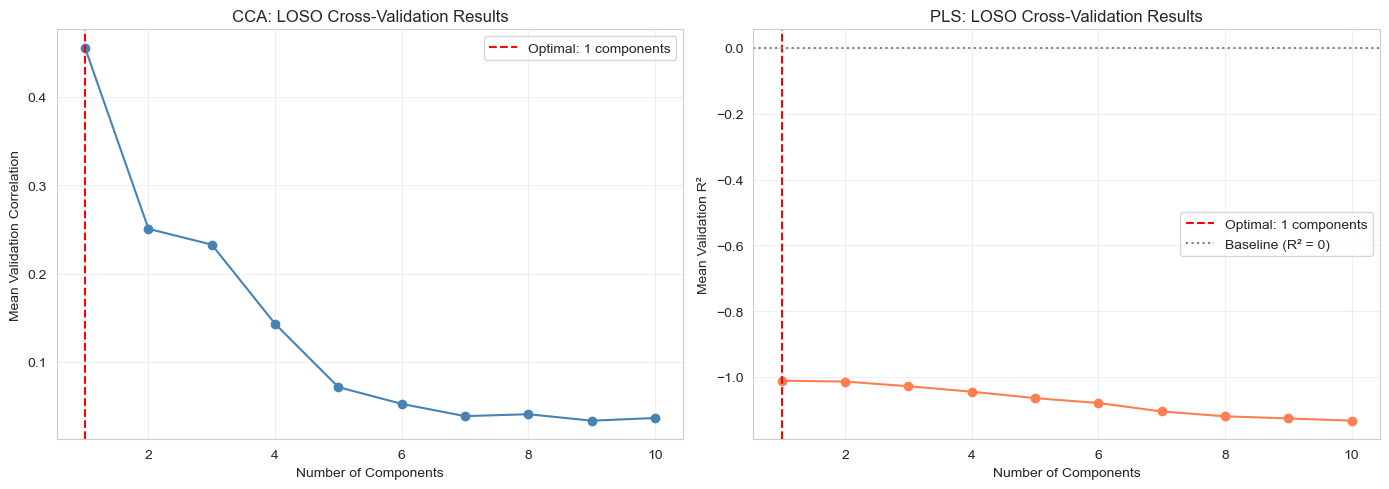

In [58]:
# Cross-validation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CCA CV results (make sure you ran CCA CV first)
try:
    axes[0].plot(range(1, len(cca_cv_scores) + 1), cca_cv_scores, 'o-', color='steelblue')
    axes[0].axvline(x=optimal_n_cca, color='red', linestyle='--', label=f'Optimal: {optimal_n_cca} components')
    axes[0].set_xlabel('Number of Components')
    axes[0].set_ylabel('Mean Validation Correlation')
    axes[0].set_title('CCA: LOSO Cross-Validation Results')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
except NameError:
    axes[0].text(0.5, 0.5, 'Run CCA CV first', ha='center', va='center')
    print("Warning: Run CCA cross-validation before this cell")

# PLS CV results
axes[1].plot(range(1, len(pls_cv_scores) + 1), pls_cv_scores, 'o-', color='coral')
axes[1].axvline(x=optimal_n_pls, color='red', linestyle='--', label=f'Optimal: {optimal_n_pls} components')
axes[1].axhline(y=0, color='gray', linestyle=':', label='Baseline (R² = 0)')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Mean Validation R²')
axes[1].set_title('PLS: LOSO Cross-Validation Results')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Canonical Correlation Analysis (CCA)

### Purpose
CCA identifies linear relationships between two sets of biosignals:
- **View A**: Heart rate features (HR_TD_Mean, HR_TD_AUC, etc.)
- **View B**: Electrodermal activity + temperature features

### Method
- Data was preprocessed with per-individual Yeo-Johnson transformation
- 5-fold cross-validation selected the optimal number of components
- Final model trained with optimal components on full dataset

### Results
- Optimal components: 1 (cross-validated correlation: 0.49)
- Final canonical correlation: 0.71 (strong relationship)
- Resting phase correlation: 0.93
- Puzzle phase correlation: 0.83

### Interpretation
The strong correlation (0.71) indicates that heart rate and EDA/temperature correlate substantially. The slightly lower correlation during puzzle (0.83 vs 0.93 at rest) may reflect decoupling of physiological systems under stress.

## Partial Least Squares (PLS) - Biosignals vs Questionnaires

### Purpose
PLS predicts self-reported emotions from biosignal features.

### Method
- X: All biosignal features (HR, EDA, TEMP)
- Y: 11 questionnaire responses (Frustrated, upset, hostile, etc.)
- 5-fold cross-validation with R² scoring selected optimal components

### Results
- Optimal components: 2 (cross-validated R²: -0.14)
- Component 1 correlation: 0.28
- Component 2 correlation: 0.17

### Interpretation
The negative cross-validated R² indicates the model performs worse than predicting the mean. This suggests biosignals in this dataset do not reliably predict self-reported emotions, consistent with the noisy nature of wearable biosignals described in the case materials.